# Task 4 – Portfolio Optimization

**Objective:** Use the TSLA 12-month forecast (Task 3) combined with historical BND and SPY
returns to build an optimized 3-asset portfolio.

Steps:
1. Build expected-return vector (TSLA from forecast, BND/SPY from CAPM or historical mean)
2. Build annualised covariance matrix from historical data
3. Compute the Efficient Frontier
4. Identify **Max-Sharpe** and **Min-Volatility** portfolios
5. Visualise frontier + optimal points, save figures and stats

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from pypfopt import EfficientFrontier, expected_returns, risk_models, plotting
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE      = Path('..')  # prod/
DATA      = BASE / 'data' / 'processed'
IMAGES    = BASE / 'notebooks' / 'images'
IMAGES.mkdir(parents=True, exist_ok=True)

RISK_FREE = 0.0425   # US 10-yr ~ 4.25 % (proxy)
print('Libraries loaded.')

Libraries loaded.


---
## 1  Load Historical Price Data

In [2]:
def load_close(ticker: str) -> pd.Series:
    """Load adjusted close prices from the processed CSV."""
    df = pd.read_csv(
        DATA / f"{ticker}_clean.csv",
        header=[0, 1],          # multi-level header (Price / Ticker)
        index_col=0,
        parse_dates=True,
        skiprows=[2]            # skip the empty 'Date' label row
    )
    # column is ('Close', TICKER)
    close = df[('Close', ticker)].dropna()
    close.index.name = 'Date'
    return close.sort_index()

tsla_close = load_close('TSLA')
bnd_close  = load_close('BND')
spy_close  = load_close('SPY')

prices = pd.concat([tsla_close, bnd_close, spy_close], axis=1)
prices.columns = ['TSLA', 'BND', 'SPY']
prices.dropna(inplace=True)

print(f"Price data shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
prices.tail(3)

Price data shape: (2775, 3)
Date range: 2015-01-02 → 2026-01-14


,TSLA,BND,SPY
Date,,,
2026-01-12,448.959991,73.975037,695.159973
2026-01-13,447.200012,74.034836,693.770020
2026-01-14,439.200012,74.184341,690.359985


---
## 2  Expected Returns

* **TSLA**: derived from the Task-3 LSTM 12-month forecast (annualised)
* **BND / SPY**: CAPM mean historical return (annualised daily log-returns × 252)

In [3]:
# ── Load Task-3 stats ─────────────────────────────────────────────────────────
with open(DATA / 'task3_stats.json') as f:
    t3 = json.load(f)

tsla_12m_return = t3['12m_forecast']['expected_return_pct'] / 100.0  # e.g. -0.3874
print(f"TSLA 12-month expected return (from LSTM forecast): {tsla_12m_return:.2%}")

# ── Historical mean returns for BND and SPY ───────────────────────────────────
log_returns = np.log(prices / prices.shift(1)).dropna()
mu_hist = log_returns.mean() * 252          # annualised

# Build the mu vector: override TSLA with forecast value
mu = mu_hist.copy()
mu['TSLA'] = tsla_12m_return

print("\nExpected annual returns:")
for ticker, ret in mu.items():
    print(f"  {ticker}: {ret:.2%}")

TSLA 12-month expected return (from LSTM forecast): -38.74%

Expected annual returns:
  TSLA: -38.74%
  BND: 1.90%
  SPY: 12.70%


---
## 3  Covariance Matrix (Ledoit-Wolf shrinkage)

In [4]:
S = risk_models.CovarianceShrinkage(prices).ledoit_wolf()
print("Annualised covariance matrix (Ledoit-Wolf):")
print(S.round(6))

Annualised covariance matrix (Ledoit-Wolf):
          TSLA       BND       SPY
TSLA  0.331836  0.001660  0.049943
BND   0.001660  0.003371  0.001008
SPY   0.049943  0.001008  0.031939


---
## 4  Efficient Frontier & Optimal Portfolios

In [5]:
# ── Max-Sharpe portfolio ───────────────────────────────────────────────────────
ef_sharpe = EfficientFrontier(mu, S)
raw_sharpe_weights = ef_sharpe.max_sharpe(risk_free_rate=RISK_FREE)
sharpe_weights = ef_sharpe.clean_weights()
sharpe_perf    = ef_sharpe.portfolio_performance(risk_free_rate=RISK_FREE, verbose=False)

print("=== Max-Sharpe Portfolio ===")
for t, w in sharpe_weights.items():
    print(f"  {t}: {w:.2%}")
print(f"  Expected Return  : {sharpe_perf[0]:.2%}")
print(f"  Volatility       : {sharpe_perf[1]:.2%}")
print(f"  Sharpe Ratio     : {sharpe_perf[2]:.4f}")

# ── Min-Volatility portfolio ───────────────────────────────────────────────────
ef_minvol = EfficientFrontier(mu, S)
raw_min_weights = ef_minvol.min_volatility()
minvol_weights  = ef_minvol.clean_weights()
minvol_perf     = ef_minvol.portfolio_performance(risk_free_rate=RISK_FREE, verbose=False)

print("\n=== Min-Volatility Portfolio ===")
for t, w in minvol_weights.items():
    print(f"  {t}: {w:.2%}")
print(f"  Expected Return  : {minvol_perf[0]:.2%}")
print(f"  Volatility       : {minvol_perf[1]:.2%}")
print(f"  Sharpe Ratio     : {minvol_perf[2]:.4f}")

=== Max-Sharpe Portfolio ===
  TSLA: 0.00%
  BND: 0.00%
  SPY: 100.00%
  Expected Return  : 12.70%
  Volatility       : 17.87%
  Sharpe Ratio     : 0.4728

=== Min-Volatility Portfolio ===
  TSLA: 0.00%
  BND: 92.90%
  SPY: 7.10%
  Expected Return  : 2.67%
  Volatility       : 5.66%
  Sharpe Ratio     : -0.2799


---
## 5  Visualisation
### 5.1  Efficient Frontier

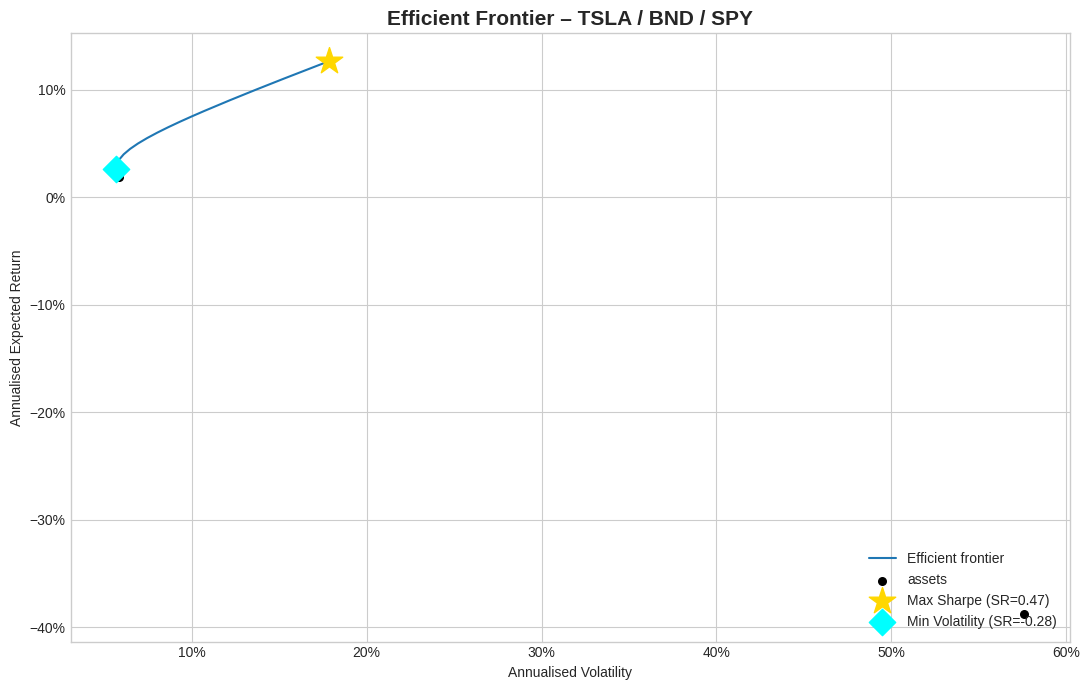

Figure 1 saved.


In [6]:
fig, ax = plt.subplots(figsize=(11, 7))

# Plot the frontier
ef_plot = EfficientFrontier(mu, S)
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True,
                                 ef_param_range=np.linspace(0, 1, 200))

# Mark Max-Sharpe
ax.scatter(sharpe_perf[1], sharpe_perf[0],
           marker='*', color='gold', s=400, zorder=5,
           label=f'Max Sharpe (SR={sharpe_perf[2]:.2f})')

# Mark Min-Vol
ax.scatter(minvol_perf[1], minvol_perf[0],
           marker='D', color='cyan', s=180, zorder=5,
           label=f'Min Volatility (SR={minvol_perf[2]:.2f})')

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title('Efficient Frontier – TSLA / BND / SPY', fontsize=15, fontweight='bold')
ax.set_xlabel('Annualised Volatility')
ax.set_ylabel('Annualised Expected Return')
ax.legend(loc='lower right')
plt.tight_layout()

fig.savefig(IMAGES / 't4_fig1_efficient_frontier.png', dpi=150)
plt.show()
print('Figure 1 saved.')

### 5.2  Portfolio Weights Comparison

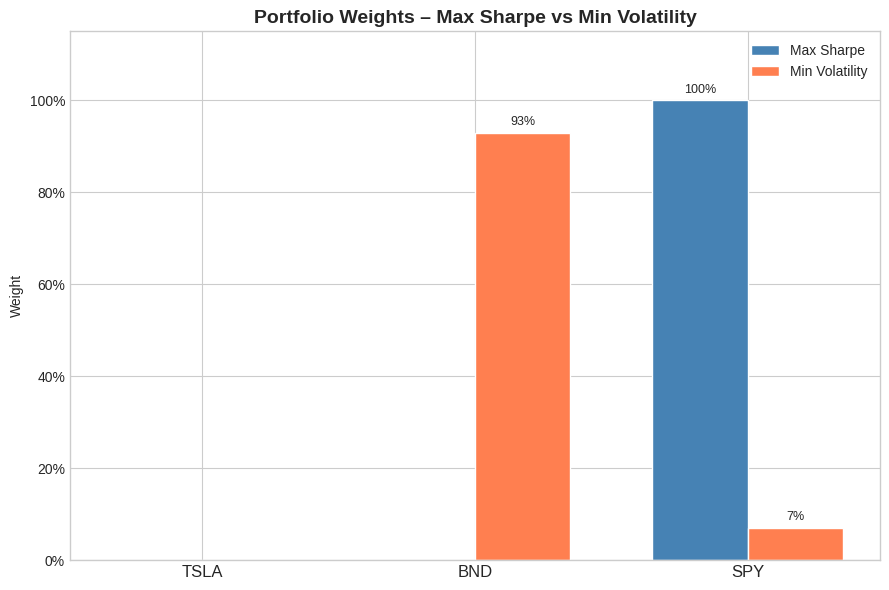

Figure 2 saved.


In [7]:
tickers = list(sharpe_weights.keys())
sw = [sharpe_weights[t] for t in tickers]
mv = [minvol_weights[t] for t in tickers]

x = np.arange(len(tickers))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, sw, width, label='Max Sharpe', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, mv, width, label='Min Volatility', color='coral', edgecolor='white')

for bar in bars1 + bars2:
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f'{h:.0%}', ha='center', va='bottom', fontsize=9)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xticks(x)
ax.set_xticklabels(tickers, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('Portfolio Weights – Max Sharpe vs Min Volatility', fontsize=14, fontweight='bold')
ax.set_ylabel('Weight')
ax.legend()
plt.tight_layout()

fig.savefig(IMAGES / 't4_fig2_portfolio_weights.png', dpi=150)
plt.show()
print('Figure 2 saved.')

### 5.3  Performance Summary Table

In [8]:
summary = pd.DataFrame({
    'Max Sharpe': {
        'TSLA weight':       sharpe_weights.get('TSLA', 0),
        'BND weight':        sharpe_weights.get('BND', 0),
        'SPY weight':        sharpe_weights.get('SPY', 0),
        'Expected Return':   sharpe_perf[0],
        'Volatility':        sharpe_perf[1],
        'Sharpe Ratio':      sharpe_perf[2],
    },
    'Min Volatility': {
        'TSLA weight':       minvol_weights.get('TSLA', 0),
        'BND weight':        minvol_weights.get('BND', 0),
        'SPY weight':        minvol_weights.get('SPY', 0),
        'Expected Return':   minvol_perf[0],
        'Volatility':        minvol_perf[1],
        'Sharpe Ratio':      minvol_perf[2],
    }
}).T

pct_cols = ['TSLA weight', 'BND weight', 'SPY weight', 'Expected Return', 'Volatility']
print("\n=== Portfolio Performance Summary ===")
print(summary.to_string())


=== Portfolio Performance Summary ===
                TSLA weight  BND weight  SPY weight  Expected Return  Volatility  Sharpe Ratio
Max Sharpe              0.0     0.00000     1.00000         0.126995    0.178716      0.472790
Min Volatility          0.0     0.92903     0.07097         0.026660    0.056598     -0.279874


---
## 6  Discrete Allocation (portfolio value = $10 000)

In [9]:
PORTFOLIO_VALUE = 10_000

latest_prices = get_latest_prices(prices)

da_sharpe = DiscreteAllocation(sharpe_weights, latest_prices,
                                total_portfolio_value=PORTFOLIO_VALUE)
alloc_sharpe, leftover_sharpe = da_sharpe.lp_portfolio()

da_minvol = DiscreteAllocation(minvol_weights, latest_prices,
                                total_portfolio_value=PORTFOLIO_VALUE)
alloc_minvol, leftover_minvol = da_minvol.lp_portfolio()

print(f"=== Discrete Allocation (${PORTFOLIO_VALUE:,} portfolio) ===")
print("\nMax-Sharpe:")
for ticker, shares in alloc_sharpe.items():
    print(f"  {ticker}: {shares} shares")
print(f"  Leftover cash: ${leftover_sharpe:.2f}")

print("\nMin-Volatility:")
for ticker, shares in alloc_minvol.items():
    print(f"  {ticker}: {shares} shares")
print(f"  Leftover cash: ${leftover_minvol:.2f}")

=== Discrete Allocation ($10,000 portfolio) ===

Max-Sharpe:
  BND: 2 shares
  SPY: 14 shares
  Leftover cash: $186.59

Min-Volatility:
  BND: 125 shares
  SPY: 1 shares
  Leftover cash: $36.60


---
## 7  Save Stats JSON

In [10]:
task4_stats = {
    "risk_free_rate": RISK_FREE,
    "expected_returns": {k: round(float(v), 6) for k, v in mu.items()},
    "max_sharpe": {
        "weights":          {k: round(float(v), 6) for k, v in sharpe_weights.items()},
        "expected_return":  round(float(sharpe_perf[0]), 6),
        "volatility":       round(float(sharpe_perf[1]), 6),
        "sharpe_ratio":     round(float(sharpe_perf[2]), 6),
    },
    "min_volatility": {
        "weights":          {k: round(float(v), 6) for k, v in minvol_weights.items()},
        "expected_return":  round(float(minvol_perf[0]), 6),
        "volatility":       round(float(minvol_perf[1]), 6),
        "sharpe_ratio":     round(float(minvol_perf[2]), 6),
    },
    "covariance_matrix": {
        ticker: {t2: round(float(S.loc[ticker, t2]), 8) for t2 in S.columns}
        for ticker in S.index
    }
}

stats_path = DATA / 'task4_stats.json'
with open(stats_path, 'w') as f:
    json.dump(task4_stats, f, indent=2)

print(f"Stats saved to {stats_path}")
print(json.dumps({
    'max_sharpe': task4_stats['max_sharpe'],
    'min_volatility': task4_stats['min_volatility']
}, indent=2))

Stats saved to ../data/processed/task4_stats.json
{
  "max_sharpe": {
    "weights": {
      "TSLA": 0.0,
      "BND": 0.0,
      "SPY": 1.0
    },
    "expected_return": 0.126995,
    "volatility": 0.178716,
    "sharpe_ratio": 0.47279
  },
  "min_volatility": {
    "weights": {
      "TSLA": 0.0,
      "BND": 0.92903,
      "SPY": 0.07097
    },
    "expected_return": 0.02666,
    "volatility": 0.056598,
    "sharpe_ratio": -0.279874
  }
}
